In [1]:
import matplotlib.pyplot as plt
import numpy as np, collections
from astropy.table import Table, join, vstack

from dataclasses import replace

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import (run_extract, run_stack, measure, validation, extract,
                            plotting, analysis, multicat, selection, core, stack)
from utils_lya_halo.stack import build_stacks
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut
from utils_lya_halo.measure import measure_all_bins
from utils_lya_halo import starpsf

LYA_REST = 1215.67

# Reading in output and stacking

In [2]:
random_seed = 10
bin_mode = 'kpc'
stack_method = 'biweight'
rest_wave_min = 1100
rest_wave_max = 1300
spexlim = (rest_wave_min, rest_wave_max)
n_bootstrap = 1000
half_width = 3.5

cfg2 = replace(cfg,
               field='BOTH',
               bin_mode=bin_mode,
               rest_wave_min=rest_wave_min,
               rest_wave_max=rest_wave_max,
               n_bootstrap=n_bootstrap,
               #flux_unit='flux_arcsec2',
               #rest_density=False,
               line_window=[LYA_REST-half_width, LYA_REST+half_width])

In [3]:
catalog_keep = Table.read('catalogs/lya_halo_catalog_cuts/lya_mosdef_catalog_KEEP.fits', format='fits')

prod_egs    = core.read_core_fits("outputs_core/6-23-26-core_extraction_egs_MF.fits")
prod_cosmos = core.read_core_fits("outputs_core/6-23-26-core_extraction_cosmos_MF.fits")

prod = stack.concat_core_prods(prod_egs, prod_cosmos)
print(f"pooled {prod['n_per_input']} -> {len(prod['core_spec'])} galaxies")

catalog_keep[:5]

pooled [244, 278] -> 522 galaxies


INDEX,FIELD,CATALOG,ID,ID_V21,ID_V41,MASKNAME,SLITOBJNAME,RA,DEC,z,Z_QUAL,HA_FLUX,HA_FLUX_ERR,HA_FWHM,HA_FWHM_ERR,HB_FLUX,HB_FLUX_ERR,HB_FWHM,HB_FWHM_ERR,HG_FLUX,HG_FLUX_ERR,HG_FWHM,HG_FWHM_ERR,HD_FLUX,HD_FLUX_ERR,HD_FWHM,HD_FWHM_ERR,OII3727_FLUX,OII3727_FLUX_ERR,OII3727_FWHM,OII3727_FWHM_ERR,OII3730_FLUX,OII3730_FLUX_ERR,OII3730_FWHM,OII3730_FWHM_ERR,OIII4364_FLUX,OIII4364_FLUX_ERR,OIII4364_FWHM,OIII4364_FWHM_ERR,OIII4960_FLUX,OIII4960_FLUX_ERR,OIII4960_FWHM,OIII4960_FWHM_ERR,OIII5008_FLUX,OIII5008_FLUX_ERR,OIII5008_FWHM,OIII5008_FWHM_ERR,OI6302_FLUX,OI6302_FLUX_ERR,OI6302_FWHM,OI6302_FWHM_ERR,NII6550_FLUX,NII6550_FLUX_ERR,NII6550_FWHM,NII6550_FWHM_ERR,NII6585_FLUX,NII6585_FLUX_ERR,NII6585_FWHM,NII6585_FWHM_ERR,SII6718_FLUX,SII6718_FLUX_ERR,SII6718_FWHM,SII6718_FWHM_ERR,SII6733_FLUX,SII6733_FLUX_ERR,SII6733_FWHM,SII6733_FWHM_ERR,NEIII3870_FLUX,NEIII3870_FLUX_ERR,NEIII3870_FWHM,NEIII3870_FWHM_ERR,NEIII3969_FLUX,NEIII3969_FLUX_ERR,NEIII3969_FWHM,NEIII3969_FWHM_ERR,NIIHA,NIIHA_ERR,MASS_50,MASS_16,MASS_84,SFR_50,SFR_16,SFR_84,SSFR_50,SSFR_16,SSFR_84,AV_50,AV_16,AV_84,AGE_50,AGE_16,AGE_84,TAU_50,TAU_16,TAU_84,CHI2,ZFAST,EBV_STAR_16,EBV_STAR_50,EBV_STAR_84,HA_SN,HA_FLAG,HB_SN,HB_FLAG,HG_SN,HG_FLAG,HD_SN,HD_FLAG,OII3727_SN,OII3727_FLAG,OII3730_SN,OII3730_FLAG,OIII4364_SN,OIII4364_FLAG,OIII4960_SN,OIII4960_FLAG,OIII5008_SN,OIII5008_FLAG,OI6302_SN,OI6302_FLAG,NII6550_SN,NII6550_FLAG,NII6585_SN,NII6585_FLAG,SII6718_SN,SII6718_FLAG,SII6733_SN,SII6733_FLAG,NEIII3870_SN,NEIII3870_FLAG,NEIII3969_SN,NEIII3969_FLAG,O3,O3_ERR,O32,O32_ERR,EBV_NEB_16,EBV_NEB_50,EBV_NEB_84,FLUX_RADIUS,A_IMAGE,B_IMAGE,THETA_J2000,KRON_RADIUS,FWHM_IMAGE,CLASS_STAR,F_F160W,E_F160W,F_F814W,E_F814W,F_F606W,E_F606W,F_G,E_G,F_R,E_R,F_V,E_V,F_IRAC1,E_IRAC1,IRAC1_CONTAM,F_IRAC2,E_IRAC2,IRAC2_CONTAM,F_IRAC3,E_IRAC3,IRAC3_CONTAM,F_IRAC4,E_IRAC4,IRAC4_CONTAM,USE_PHOT,STAR_FLAG,PHOT_FLAGS,Z_SPEC,TOT_COR,SKELTON_MATCH,BA,INCL_DEG,GALFIT_FLAG_F160W,GALFIT_MAG_F160W,GALFIT_MAG_ERR_F160W,RE_F160W,RE_ERR_F160W,N_F160W,N_ERR_F160W,Q_F160W,Q_ERR_F160W,PA_F160W,PA_ERR_F160W,SN_F160W,VDW_MATCH_F160W,GALFIT_FLAG_F125W,GALFIT_MAG_F125W,GALFIT_MAG_ERR_F125W,RE_F125W,RE_ERR_F125W,N_F125W,N_ERR_F125W,Q_F125W,Q_ERR_F125W,PA_F125W,PA_ERR_F125W,SN_F125W,VDW_MATCH_F125W,RE_BEST,RE_BEST_SRC,Q_BEST,Q_BEST_SRC,RE_CIRC_BEST,MAG_G,MAG_R,MAG_V,MAG_F606W,MAG_F814W,MAG_F160W,GR_COLOR,Z_SECURE,Z_INWINDOW,BEST_LINE_SN,LINE_SN_OK,COORDS_OK,SAMPLE,HAS_DUP_0p5AS,DUP_DROP,BLEND_DROP,BLEND_MERGE,KEEP,XRAY_MATCH,XRAY_SEP_AS,XRAY_NAME,XRAY_FLUX_B,XRAY_SIG,AGN_XRAY,NIIHA_OK,BPT_O3HB,BPT_N2HA,AGN_OPT_USABLE,AGN_OPT,DONLEY_X,DONLEY_Y,AGN_IR_USABLE,AGN_IR,AGN_FLAG,CLEAN,MEX_O3HB,AGN_MEX,MEX_INTERMED,AGN_MEX_USABLE,AGN_MEX_APPLIED,VALID,EBV
int64,bytes6,bytes6,int64,int64,int64,bytes8,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,f

In [4]:
# ---- AGN separation (your code) ----
mask_clean = prod["catalog"]["CLEAN"]
mask_agn   = prod["catalog"]["AGN_FLAG"]
print(np.sum(mask_clean), np.sum(mask_agn))

stack_gal = core.build_core_stacks(cfg2, prod, mask=mask_clean, output="flux")
stack_agn = core.build_core_stacks(cfg2, prod, mask=mask_agn,   output="flux")

446 76
[core] 'weighted_median' skipped: core product has no 'nfib_used' weights (radial-stack method; not needed for the single-aperture core).
[core] 'weighted_median' skipped: core product has no 'nfib_used' weights (radial-stack method; not needed for the single-aperture core).


# Spectral Background Subtraction Tests

In [5]:
prod = core.read_core_fits("outputs_core/6-23-26-core_extraction_egs_MF.fits")
Spec = np.asarray(prod["core_spec"])
allnan = np.all(~np.isfinite(Spec), axis=1)
print(f"all-NaN cores: {allnan.sum()} / {len(Spec)}")

all-NaN cores: 55 / 244


In [6]:
# 0. FIRST check what the old catalog actually calls its coordinate columns:
print(prod["catalog"].colnames)          # look for RA/DEC naming (RA/DEC? ra/dec? ALPHA/DELTA?)

# 1. the all-NaN galaxies, taken by POSITION (the mask is positional over the axis)
allnan  = np.all(~np.isfinite(np.asarray(prod["core_spec"])), axis=1)
nan_cat = prod["catalog"][allnan].copy()
nan_cat["ROW"] = np.arange(len(nan_cat))     # a guaranteed-unique id, scheme-independent
print(f"{allnan.sum()} all-NaN cores")

# 2. diagnose by RA/DEC under the CURRENT cfg (segmap + current annulus)
vdfi = extract.load_field(cfg)               # cfg.field must match this product's field
diag = core.diagnose_core_fibers(
    cfg, list(nan_cat["ROW"]), vdfi=vdfi,
    run_table=nan_cat, id_col="ROW",
    ra_col="RA", dec_col="DEC",              # <-- set these to whatever colnames printed above
)

# 3. tally the causes
tally = collections.Counter(np.asarray(diag["verdict"]))
for verdict, n in tally.most_common():
    print(f"{n:3d}  {verdict}")

['INDEX', 'FIELD', 'CATALOG', 'ID', 'ID_V21', 'ID_V41', 'MASKNAME', 'SLITOBJNAME', 'RA', 'DEC', 'z', 'Z_QUAL', 'HA_FLUX', 'HA_FLUX_ERR', 'HA_FWHM', 'HA_FWHM_ERR', 'HB_FLUX', 'HB_FLUX_ERR', 'HB_FWHM', 'HB_FWHM_ERR', 'HG_FLUX', 'HG_FLUX_ERR', 'HG_FWHM', 'HG_FWHM_ERR', 'HD_FLUX', 'HD_FLUX_ERR', 'HD_FWHM', 'HD_FWHM_ERR', 'OII3727_FLUX', 'OII3727_FLUX_ERR', 'OII3727_FWHM', 'OII3727_FWHM_ERR', 'OII3730_FLUX', 'OII3730_FLUX_ERR', 'OII3730_FWHM', 'OII3730_FWHM_ERR', 'OIII4364_FLUX', 'OIII4364_FLUX_ERR', 'OIII4364_FWHM', 'OIII4364_FWHM_ERR', 'OIII4960_FLUX', 'OIII4960_FLUX_ERR', 'OIII4960_FWHM', 'OIII4960_FWHM_ERR', 'OIII5008_FLUX', 'OIII5008_FLUX_ERR', 'OIII5008_FWHM', 'OIII5008_FWHM_ERR', 'OI6302_FLUX', 'OI6302_FLUX_ERR', 'OI6302_FWHM', 'OI6302_FWHM_ERR', 'NII6550_FLUX', 'NII6550_FLUX_ERR', 'NII6550_FWHM', 'NII6550_FWHM_ERR', 'NII6585_FLUX', 'NII6585_FLUX_ERR', 'NII6585_FWHM', 'NII6585_FWHM_ERR', 'SII6718_FLUX', 'SII6718_FLUX_ERR', 'SII6718_FWHM', 'SII6718_FWHM_ERR', 'SII6733_FLUX', 'SII6733_

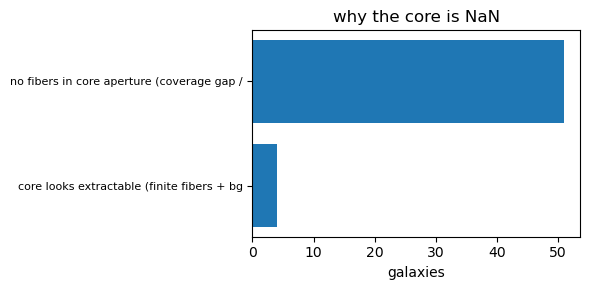

In [7]:
labels, counts = zip(*tally.most_common())
plt.figure(figsize=(6, 3))
plt.barh(range(len(counts)), counts)
plt.yticks(range(len(counts)), [l[:42] for l in labels], fontsize=8)
plt.xlabel("galaxies"); plt.title("why the core is NaN"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

In [20]:
id_col = 'ID'

cfg2 = replace(cfg, 
    catalog_path="catalogs/lya_halo_catalog_cuts/lya_mosdef_catalog_KEEP.fits",
    field='AEGIS')

vdfi = extract.load_field(cfg2)
run_table = extract.build_run_table(cfg2)

Loaded AEGIS: 141 exposures, 34944 fibers, 1036 wavelength pixels


In [25]:
# pick a few galaxies you want to inspect (e.g. your regression IDs, or any core-spectrum outliers)
bg = core.inspect_core_background(cfg2, [17632, 30032], vdfi=vdfi,
                                  run_table=run_table, id_col=id_col)

d = bg[30032]
print("bg mean (raw):", np.nanmean(d["bg_gal_raw"]))
print("fibers contributing to this galaxy's background:", d["n_bg_fibers_total"])

Same RA and bad_fiber_mask shape? True
Bad fibers: 500106
Good fibers: 4426998
Fraction bad: 0.102
Fibers off mask footprint: 0.000%
bg mean (raw): 0.0033174749
fibers contributing to this galaxy's background: 13502


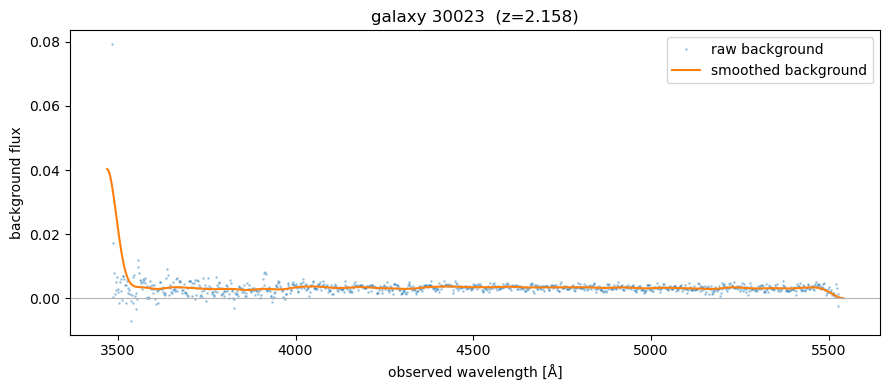

In [27]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(d["wave"], d["bg_gal_raw"], ".", ms=2, alpha=0.3, label="raw background")
ax.plot(d["wave"], d["bg_gal_smooth"], "C1-", lw=1.5, label="smoothed background")
ax.axhline(0, color="0.7", lw=0.8)
ax.set_xlabel("observed wavelength [Å]"); ax.set_ylabel("background flux")
ax.set_title(f"galaxy {30023}  (z={d['z']:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
sample_ids = catalog["ID"][:40]     # representative subsample; scale up once it looks sane

variants = {
    "57-63 (current)": {"bg_inner_arcsec": 57.0, "bg_outer_arcsec": 63.0},
    "40-50":           {"bg_inner_arcsec": 40.0, "bg_outer_arcsec": 50.0},
    "30-40":           {"bg_inner_arcsec": 30.0, "bg_outer_arcsec": 40.0},
    "20-30":           {"bg_inner_arcsec": 20.0, "bg_outer_arcsec": 30.0},
}
results = compare_background_variants(cfg2, sample_ids, variants, vdfi=vdfi)

# plot: does the stacked subtracted background move with annulus?
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color="k", lw=0.8)
for label, r in results.items():
    ax.plot(r["rest_wave"], r["stacked_bg"], lw=1.3, label=label)
ax.set_xlabel("rest wavelength (A)"); ax.set_ylabel("stacked subtracted background")
ax.legend(); plt.show()

# is the level trend universal, or driven by a few galaxies?
for label, r in results.items():
    forest = (r["rest_wave"] > 1100) & (r["rest_wave"] < LYA_REST)
    per_gal = np.nanmedian(r["per_galaxy_bg"][:, forest], axis=1)   # one value per galaxy
    print(f"{label:16s} forest bg: median={np.nanmedian(per_gal):+.4f}  "
          f"spread(16-84)={np.nanpercentile(per_gal,16):+.4f}..{np.nanpercentile(per_gal,84):+.4f}")

# Injection-Recovery Completeness Tests

In [8]:
# ---- characterize the CLEAN sample (the arrays live inside prod) ----
sel        = np.asarray(mask_clean, bool)
Spec       = np.asarray(prod["core_spec"])[sel]      # (ngal, nwave) observed-frame
Err        = np.asarray(prod["core_err"])[sel]
wave_obs   = np.asarray(prod["wave_obs"])            # (nwave,)
catalog    = prod["catalog"][sel]

In [11]:
# run everything, with real (non-default) settings exposed for each sub-tool
cc = validation.run_core_characterization(
    Spec, Err, wave_obs, catalog,
    z_col="z",
    # synthetic-noise injection (bias + floor):
    syn_input_fluxes=(0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0), syn_sigma_A=1.5, syn_n_real=500,
    syn_methods=("integration", "gaussian", "matched_filter"),
    # real-noise injection (completeness):
    samp_input_snrs=(0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0), samp_method="matched_filter",
    samp_n_real_per_gal=20,
    # redshift null (false-positive rate):
    null_method="matched_filter", null_n_permutations=50,
    # estimator agreement on one example galaxy:
    compare_index=0,
)


[integration]  sigma_A=1.5 A, 500 reals
    F_in      F_rec       bias    scatter    det%
       0        nan        nan        nan       0
     0.5        nan        nan        nan       0
       1        nan        nan        nan       0
       2        nan        nan        nan       0
       3        nan        nan        nan       0
       4        nan        nan        nan       0
       5        nan        nan        nan       0

[gaussian]  sigma_A=1.5 A, 500 reals
    F_in      F_rec       bias    scatter    det%
       0        nan        nan        nan       0
     0.5        nan        nan        nan       0
       1        nan        nan        nan       0
       2        nan        nan        nan       0
       3        nan        nan        nan       0
       4        nan        nan        nan       0
       5        nan        nan        nan       0

[matched_filter]  sigma_A=1.5 A, 500 reals
    F_in      F_rec       bias    scatter    det%
       0        nan        

inj-rec sample:   0%|          | 0/446 [00:00<?, ?it/s]


injection_recovery_sample [matched_filter] (446 galaxies, 20 reals each)
  SNR_in    completeness    bias/σ_F
    0.00           0.033       0.002
    0.50           0.078       0.007
    1.00           0.157      -0.025
    2.00           0.414      -0.008
    3.00           0.681       0.024
    4.00           0.795      -0.004
    5.00           0.826      -0.027


/home/jovyan/work/ls6/VIRAL-Halos/astrickler/utils_lya_halo/measure.py:101: RuntimeWarning: All-NaN slice encountered
  return np.full_like(wave, np.nanmedian(flux))



null_redshift_test [matched_filter] (50 permutations, 446 galaxies)
  null flux median over sample: -0.004762
  null flux std   over sample: 1.251
run_core_characterization: ran synthetic, sample, null, compare


In [8]:
# 1. completeness vs input S/N (from the real-noise injection): where the sample turns over
x, rate = cc["completeness"]["sample"]
plt.figure(figsize=(5,4))
plt.plot(x, rate, "o-"); plt.axhline(0.5, ls=":", c="grey")
plt.xlabel("input S/N"); plt.ylabel("recovery fraction")
plt.title("CLEAN core completeness"); plt.show()

# 2. redshift null: measured "Lya" flux at the WRONG z should sit at ~0
nf = cc["null"]["null_flux"]
plt.figure(figsize=(5,4))
plt.hist(nf[np.isfinite(nf)], bins=30)
plt.axvline(0, c="k", lw=1); plt.xlabel("null flux (wrong-z)")
plt.title("false-positive null"); plt.show()
print(f"null flux: median={np.nanmedian(nf):.3g}, 84th pct={np.nanpercentile(nf,84):.3g}")

NameError: name 'cc' is not defined